<a href="https://colab.research.google.com/github/TanuSree02/Deep-learning/blob/main/RNN_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6349 - loss: 0.6182 - val_accuracy: 0.7678 - val_loss: 0.4890
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.8206 - loss: 0.4026 - val_accuracy: 0.8076 - val_loss: 0.4441
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.9250 - loss: 0.1959 - val_accuracy: 0.8068 - val_loss: 0.4739
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9771 - loss: 0.0754 - val_accuracy: 0.7948 - val_loss: 0.6043
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9948 - loss: 0.0252 - val_accuracy: 0.8014 - val_loss: 0.6695
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7996 - loss: 0.6676
Test accuracy : 0.7996000051498413


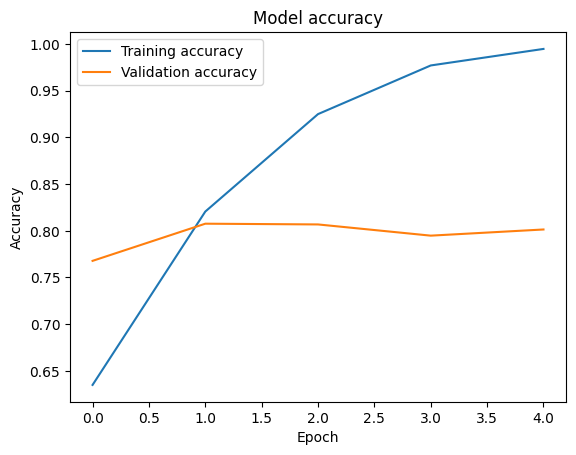

In [1]:
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

import matplotlib.pyplot as plt


vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)


max_length = 200

x_train = pad_sequences(
    x_train,
    maxlen=max_length
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length
)


model = Sequential()


model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    )
)


model.add(
    SimpleRNN(32)
)


model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test accuracy :", test_acc)


plt.plot(
    history.history['accuracy'],
    label="Training accuracy"
)

plt.plot(
    history.history['val_accuracy'],
    label="Validation accuracy"
)

plt.legend()

plt.title("Model accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()